<a href="https://colab.research.google.com/github/mf2056/F20AA_CW2/blob/main/CW2_(Google_Maps).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**F20AA – Applied Text Analytics**   

## Coursework 2 – Google Maps

Group 5 UG:
* Mohamed Hafeez Mohamed Ferose
* Mohamed Ihsan Fazal  
* Sri Sai Vaishnavi Chintha

## Data Exploration and Visualization: (5%)

### Environment Setup
I’m using Pandas for the data, Seaborn for the charts, and NLTK to help clean up the text so the results aren't just full of "noise."

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter

Loading in the CSVs and doing a quick shape check. I want to make sure the text and ratings columns look right before moving forward.

In [ ]:
# Load the datasets into variables
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# Verify they loaded correctly
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(train.head())

Train shape: (288000, 2)
Test shape: (89100, 2)
                                                text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4


Checking for any empty rows here. I’m also adding columns for character and word counts to see if there's a link between review length and the actual star rating.

In [ ]:
# Check for null entries
print(f"Total Training Samples: {train.shape[0]}")
print(f"Missing Values:\n{train.isnull().sum()}")

# Calculate Review Lengths (Characters and Words)
train['char_count'] = train['text'].astype(str).apply(len)
train['word_count'] = train['text'].astype(str).apply(lambda x: len(x.split()))

Total Training Samples: 288000
Missing Values:
text      0
rating    0
dtype: int64


### Rating Distribution
This chart shows the class balance. It's pretty clear that 1-star reviews dominate the set, which is a huge heads-up that I'll need to handle class imbalance later on.

/tmp/ipykernel_22882/1686532641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='rating', data=train, palette='viridis')


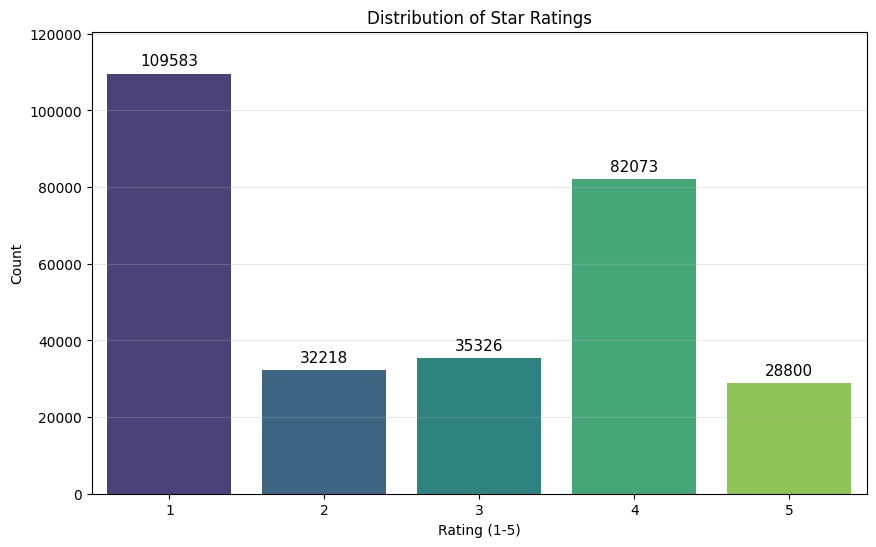

In [ ]:
# Visualize class balance/imbalance across the 1-5 star ratings
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='rating', data=train, palette='viridis')

# Add the count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11,)

plt.title('Distribution of Star Ratings')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, train['rating'].value_counts().max() * 1.1)

plt.show()

### Length Comparison
Using boxplots to compare review lengths. It’s interesting to see the medians—unhappy customers seem to have a lot more to say than the ones leaving 4 or 5 stars.

/tmp/ipykernel_22882/1288500574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='rating', y='word_count', data=train,


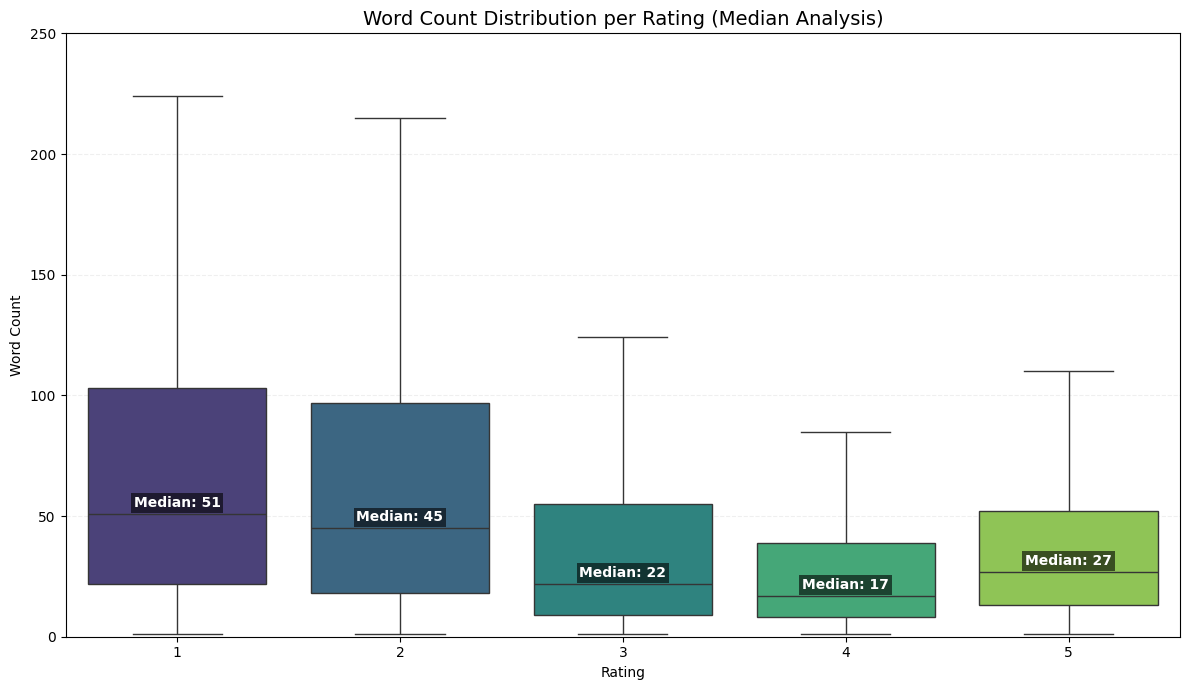

In [ ]:
# Boxplot visualization to compare word count distributions across ratings
plt.figure(figsize=(12, 7))
ax = sns.boxplot(x='rating', y='word_count', data=train,
                 showfliers=False, palette='viridis')

# Overlay median labels for precise quantitative comparison
medians = train.groupby(['rating'])['word_count'].median().values
for i, median in enumerate(medians):
    ax.text(i, median + 1.5, f'Median: {int(median)}',
            ha='center', va='bottom', fontweight='bold', color='white',
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=2))

plt.title('Word Count Distribution per Rating (Median Analysis)', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.grid(axis='y', alpha=0.2, linestyle='--')
plt.ylim(0, 250)
plt.tight_layout()
plt.show()

### Keyword Extraction
To find the real "why" behind the ratings, I've built a custom filter. By stripping out generic words like "place" or "time," I can see the specific terms that actually drive a 1-star vs. a 5-star experience.

In [ ]:
# Initialize NLP resources for keyword extraction
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Extend stopwords with context-specific auxiliary verbs
stop_words.update([])

custom_stops = [
    'this', 'that', 'they', 'have', 'had', 'are', 'was', 'were',
    'be', 'been', 'being', 'would', 'get', 'got', 'go', 'went',
    'one', 'even', 'could', 'back', 'like', 'really', 'also',
    'told', 'said', 'asked', 'going', 'give', 'still', 'another',
    'made', 'work', 'new', 'make', 'come', 'came', 'called', 'call',
    'day', 'want', 'first', 'know', 'people', 'phone', 'customer',
    'place', 'service', 'time', 'us', 'take', 'way', 'company',
    'money', 'office', 'staff', 'car', 'ever', 'business', 'see',
    'next', 'good', 'recommend', 'experience', 'care', 'two',
    'someone', 'put', 'say', 'tell', 'everything', 'every', 'always'
]
stop_words.update(custom_stops)

def get_most_common(rating, num_words=20):
    # Extracts top tokens for a specific rating excluding stopwords.
    text_data = train[train['rating']==rating]['text'].str.lower()

    all_words = []
    for review in text_data:
        words = review.split()
        filtered = [w for w in words if w.isalpha() and w not in stop_words]
        all_words.extend(filtered)

    return Counter(all_words).most_common(num_words)

# Display thematic differences between extreme ratings
print("--- Top 20 Negative Sentiment Keywords (1-Star) ---")
print(get_most_common(1))

print("\n--- Top 20 Positive Sentiment Keywords (5-Star) ---")
print(get_most_common(5))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- Top 20 Negative Sentiment Keywords (1-Star) ---
[('never', 27878), ('rude', 10900), ('worst', 10380), ('pay', 9654), ('bad', 9432), ('took', 9233), ('appointment', 8996), ('need', 8301), ('left', 7911), ('horrible', 7447), ('times', 7019), ('days', 6926), ('since', 6778), ('use', 6713), ('help', 6516), ('hours', 6503), ('find', 6461), ('wait', 6318), ('done', 6257), ('minutes', 6212)]

--- Top 20 Positive Sentiment Keywords (5-Star) ---
[('great', 9239), ('best', 3628), ('highly', 3594), ('thank', 2718), ('friendly', 2687), ('love', 2495), ('professional', 2282), ('amazing', 1989), ('definitely', 1894), ('nice', 1880), ('excellent', 1863), ('job', 1728), ('feel', 1606), ('helpful', 1422), ('well', 1373), ('years', 1353), ('help', 1353), ('happy', 1292), ('super', 1282), ('took', 1281)]


# Model training, selection and hyperparameter tuning and evaluation:(20%)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import classification_report

In [ ]:
import pandas as pd

train = pd.read_csv("train_processed.csv")

train.head()

,text,rating,tokens,stemmed,lemmatized,text_stem,text_lemma,review_length
0,this place is terrible the people in charge ar...,2,"['place', 'terrible', 'people', 'charge', 'wor...","['place', 'terribl', 'peopl', 'charg', 'worst'...","['place', 'terrible', 'people', 'charge', 'wor...",place terribl peopl charg worst part far yeah ...,place terrible people charge worst part far ye...,97
1,terrible service and they are saying that i ne...,1,"['terrible', 'service', 'saying', 'never', 'us...","['terribl', 'servic', 'say', 'never', 'use', '...","['terrible', 'service', 'saying', 'never', 'us...",terribl servic say never use servic lie call n...,terrible service saying never used service lie...,48
2,absolutely terrible company they sent me to co...,1,"['absolutely', 'terrible', 'company', 'sent', ...","['absolut', 'terribl', 'compani', 'sent', 'col...","['absolutely', 'terrible', 'company', 'sent', ...",absolut terribl compani sent collect without a...,absolutely terrible company sent collection wi...,211
3,to find it either park in front of the tuesday...,4,"['find', 'either', 'park', 'front', 'tuesday',...","['find', 'either', 'park', 'front', 'tuesday',...","['find', 'either', 'park', 'front', 'tuesday',...",find either park front tuesday morn mall entra...,find either park front tuesday morning mall en...,66
4,mall location used their services for sedan ni...,4,"['mall', 'location', 'used', 'services', 'seda...","['mall', 'locat', 'use', 'servic', 'sedan', 'n...","['mall', 'location', 'used', 'service', 'sedan...",mall locat use servic sedan nice perhap inform...,mall location used service sedan nice perhaps ...,28


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
train["text_lemma"] = train["text_lemma"].fillna("")
train["text_lemma"] = train["text_lemma"].astype(str)

train["text_stem"] = train["text_stem"].fillna("")
train["text_stem"] = train["text_stem"].astype(str)

train["text"] = train["text"].fillna("")
train["text"] = train["text"].astype(str)

X_d = train["text"]
X = train["text_lemma"]
x = train["text_stem"]
Y = train["rating"]

In [ ]:
train.isnull().sum()

text             0
rating           0
tokens           0
stemmed          0
lemmatized       0
text_stem        0
text_lemma       0
review_length    0
dtype: int64

# Grid Search and Evaluation

Performs hyperparameter tuning using 3-fold cross-validation. Both accuracy and macro-F1 are evaluated, with macro-F1 selected as the primary metric to account for class imbalance. Detailed fold results are included for comparison.

Experiments were conducted on **lemmatized text**.

In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV

def run_gridsearch(name, pipeline, params):
    # 1. Define multiple metrics
    scoring = {
        'Accuracy': 'accuracy',
        'MacroF1': 'f1_macro'
    }

    grid = GridSearchCV(
        pipeline,
        params,
        cv=3,
        n_jobs=-1,
        verbose=1,
        scoring=scoring,
        refit='MacroF1',
        return_train_score=False
    )

    grid.fit(X, Y)

    # 2. Extract detailed results into a table
    results_df = pd.DataFrame(grid.cv_results_)

    # Select columns for the 3 folds and the means
    columns_to_show = ['params']
    # Add Accuracy columns
    columns_to_show += ['split0_test_Accuracy', 'split1_test_Accuracy', 'split2_test_Accuracy', 'mean_test_Accuracy']
    # Add F1 columns
    columns_to_show += ['split0_test_MacroF1', 'split1_test_MacroF1', 'split2_test_MacroF1', 'mean_test_MacroF1']

    report_table = results_df[columns_to_show].sort_values('mean_test_MacroF1', ascending=False)

    print(f"\n==== {name} DETAILED FOLD RESULTS ====")
    print(report_table.to_string(index=False))

    # 3. Print the absolute bests
    best_f1_idx = results_df['mean_test_MacroF1'].idxmax()
    best_acc_idx = results_df['mean_test_Accuracy'].idxmax()

    print(f"\n--- {name} Summary ---")
    print(f"Best Params (for F1): {grid.best_params_}")
    print(f"Best Mean Macro-F1: {results_df.loc[best_f1_idx, 'mean_test_MacroF1']:.4f}")
    print(f"Best Mean Accuracy: {results_df.loc[best_acc_idx, 'mean_test_Accuracy']:.4f}")

    return grid

# Naive Bayes

In [ ]:
import joblib
from joblib import parallel_backend

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

nb_params = {
    "clf__alpha": [0.1, 0.5, 1.0],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000, 20000, 50000]
}

with parallel_backend('threading'):
    nb_grid = run_gridsearch(
        "Naive Bayes",
        nb_pipeline,
        nb_params
    )

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== Naive Bayes DETAILED FOLD RESULTS ====
                                                                         params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
{'clf__alpha': 0.1, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.637219              0.636490              0.635531            0.636413             0.465647             0.465948             0.465692           0.465763
{'clf__alpha': 0.1, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.635490              0.634865              0.634031            0.634795             0.455449             0.456240             0.457453           0.456381
{'clf__alpha': 0.5, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.635573              0.634500              0.634583     

# Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

lr_params = {
    "clf__C": [0.5, 1, 3],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000, 20000, 50000]
}

with parallel_backend('threading'):
    lr_grid = run_gridsearch(
        "Logistic Regression",
        lr_pipeline,
        lr_params
    )

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== Logistic Regression DETAILED FOLD RESULTS ====
                                                                     params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
  {'clf__C': 3, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.648646              0.646969              0.647500            0.647705             0.510599             0.509157             0.512691           0.510815
  {'clf__C': 3, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}              0.652115              0.649823              0.650417            0.650785             0.510937             0.508166             0.511990           0.510364
  {'clf__C': 3, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.646417              0.645062              0.646969            0

# Linear SVC

In [ ]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
    )),
    ("clf", LinearSVC())
])

svm_params = {
    "clf__C": [0.5, 1, 2],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000, 20000, 50000]
}

with parallel_backend('threading'):
    svm_grid = run_gridsearch(
        "SVM",
        svm_pipeline,
        svm_params
    )

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== SVM DETAILED FOLD RESULTS ====
                                                                     params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
  {'clf__C': 2, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.636656              0.635792              0.636021            0.636156             0.489737             0.489656             0.493750           0.491048
{'clf__C': 0.5, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.644813              0.643302              0.643271            0.643795             0.489780             0.489879             0.493298           0.490985
  {'clf__C': 1, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.632365              0.631375              0.631531            0.631757         

#SGD Classifier

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()), # Parameters handled by grid
    ("clf", SGDClassifier(max_iter=1000, tol=1e-3, random_state=25))
])


sgd_params = {
    "clf__alpha": [0.0001, 0.001, 0.01],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000,20000, 50000]
}

with parallel_backend('threading'):
    sgd_grid = run_gridsearch("SGD Classifier", sgd_pipeline, sgd_params)

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== SGD Classifier DETAILED FOLD RESULTS ====
                                                                            params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
{'clf__alpha': 0.0001, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}              0.635687              0.633729              0.633042            0.634153             0.403259             0.402127             0.403054           0.402813
{'clf__alpha': 0.0001, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.634667              0.632823              0.632656            0.633382             0.399555             0.399090             0.400321           0.399656
{'clf__alpha': 0.0001, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}              0.633646              0.630354            

# Ridge Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

ridge_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", RidgeClassifier(random_state=28))
])

ridge_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],  # Comparison requirement [cite: 39]
    "tfidf__max_features": [10000,20000, 50000],   # Representation requirement [cite: 38]
    "clf__alpha": [0.1, 1.0, 10.0]           # The "knob" for regularization
}

with parallel_backend('threading'):
    ridge_grid = run_gridsearch("Ridge Classifier", ridge_pipeline, ridge_params)

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== Ridge Classifier DETAILED FOLD RESULTS ====
                                                                          params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
 {'clf__alpha': 1.0, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.642333              0.640552              0.640708            0.641198             0.476529             0.475884             0.479256           0.477223
 {'clf__alpha': 0.1, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.637708              0.635792              0.637271            0.636924             0.473907             0.472687             0.478451           0.475015
 {'clf__alpha': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.645969              0.643896              0.64

# Grid Search and Evaluation

Performs hyperparameter tuning using 3-fold cross-validation. Both accuracy and macro-F1 are evaluated, with macro-F1 selected as the primary metric to account for class imbalance. Detailed fold results are included for comparison.

Experiments were conducted on **stemming text**.

In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV

def run_gridsearch(name, pipeline, params):
    # 1. Define multiple metrics
    scoring = {
        'Accuracy': 'accuracy',
        'MacroF1': 'f1_macro'
    }

    grid_st = GridSearchCV(
        pipeline,
        params,
        cv=3,
        n_jobs=-1,
        verbose=1,
        scoring=scoring,
        refit='MacroF1',
        return_train_score=False
    )

    grid_st.fit(x, Y)

    # 2. Extract detailed results into a table
    results_df = pd.DataFrame(grid_st.cv_results_)

    # Select columns for the 3 folds and the means
    columns_to_show = ['params']
    # Add Accuracy columns
    columns_to_show += ['split0_test_Accuracy', 'split1_test_Accuracy', 'split2_test_Accuracy', 'mean_test_Accuracy']
    # Add F1 columns
    columns_to_show += ['split0_test_MacroF1', 'split1_test_MacroF1', 'split2_test_MacroF1', 'mean_test_MacroF1']

    report_table = results_df[columns_to_show].sort_values('mean_test_MacroF1', ascending=False)

    print(f"\n==== {name} DETAILED FOLD RESULTS ====")
    print(report_table.to_string(index=False))

    # 3. Print the absolute bests
    best_f1_idx = results_df['mean_test_MacroF1'].idxmax()
    best_acc_idx = results_df['mean_test_Accuracy'].idxmax()

    print(f"\n--- {name} Summary ---")
    print(f"Best Params (for F1): {grid_st.best_params_}")
    print(f"Best Mean Macro-F1: {results_df.loc[best_f1_idx, 'mean_test_MacroF1']:.4f}")
    print(f"Best Mean Accuracy: {results_df.loc[best_acc_idx, 'mean_test_Accuracy']:.4f}")

    return grid_st

# Naive Bayes

In [ ]:
import joblib
from joblib import parallel_backend

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

nb_params = {
    "clf__alpha": [0.1, 0.5, 1.0],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000, 20000, 50000]
}

with parallel_backend('threading'):
    nb_grid = run_gridsearch(
        "Naive Bayes",
        nb_pipeline,
        nb_params
    )

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== Naive Bayes DETAILED FOLD RESULTS ====
                                                                         params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
{'clf__alpha': 0.1, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.635104              0.634896              0.633302            0.634434             0.462244             0.462969             0.462135           0.462449
{'clf__alpha': 0.1, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.633677              0.633135              0.631708            0.632840             0.452543             0.454890             0.453445           0.453626
{'clf__alpha': 0.5, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.634208              0.633521              0.631927     

# Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

lr_params = {
    "clf__C": [0.5, 1, 3],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000, 20000, 50000]
}

with parallel_backend('threading'):
    lr_grid = run_gridsearch(
        "Logistic Regression",
        lr_pipeline,
        lr_params
    )

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== Logistic Regression DETAILED FOLD RESULTS ====
                                                                     params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
  {'clf__C': 3, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.648010              0.647042              0.646698            0.647250             0.509235             0.509063             0.512284           0.510194
  {'clf__C': 3, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}              0.650927              0.650792              0.649615            0.650444             0.509764             0.508159             0.511294           0.509739
  {'clf__C': 3, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.644167              0.644635              0.643698            0

# Linear SVC

In [ ]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
    )),
    ("clf", LinearSVC())
])

svm_params = {
    "clf__C": [0.5, 1, 2],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000, 20000, 50000]
}

with parallel_backend('threading'):
    svm_grid = run_gridsearch(
        "SVM",
        svm_pipeline,
        svm_params
    )

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== SVM DETAILED FOLD RESULTS ====
                                                                     params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
{'clf__C': 0.5, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.642458              0.641979              0.641698            0.642045             0.488456             0.488385             0.490384           0.489075
  {'clf__C': 1, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.641208              0.640437              0.640740            0.640795             0.487792             0.487575             0.491707           0.489024
  {'clf__C': 2, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.634854              0.633437              0.634781            0.634358         

# SGD Classifier

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()), # Parameters handled by grid
    ("clf", SGDClassifier(max_iter=1000, tol=1e-3, random_state=25))
])


sgd_params = {
    "clf__alpha": [0.0001, 0.001, 0.01],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000,20000, 50000]
}

with parallel_backend('threading'):
    sgd_grid = run_gridsearch("SGD Classifier", sgd_pipeline, sgd_params)

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== SGD Classifier DETAILED FOLD RESULTS ====
                                                                            params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
{'clf__alpha': 0.0001, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}              0.634062              0.633708              0.633646            0.633806             0.402792             0.402921             0.405125           0.403613
{'clf__alpha': 0.0001, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.633542              0.632656              0.632594            0.632931             0.399818             0.400024             0.401631           0.400491
{'clf__alpha': 0.0001, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}              0.631469              0.629448            

# Ridge Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

ridge_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", RidgeClassifier(random_state=28))
])

ridge_params = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],  # Comparison requirement [cite: 39]
    "tfidf__max_features": [10000,20000, 50000],   # Representation requirement [cite: 38]
    "clf__alpha": [0.1, 1.0, 10.0]           # The "knob" for regularization
}

with parallel_backend('threading'):
    ridge_grid = run_gridsearch("Ridge Classifier", ridge_pipeline, ridge_params)

Fitting 3 folds for each of 18 candidates, totalling 54 fits

==== Ridge Classifier DETAILED FOLD RESULTS ====
                                                                          params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
 {'clf__alpha': 1.0, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}              0.639760              0.638823              0.639448            0.639344             0.474423             0.473702             0.477432           0.475186
 {'clf__alpha': 0.1, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.637323              0.634927              0.636156            0.636135             0.473857             0.471603             0.477052           0.474171
 {'clf__alpha': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}              0.645250              0.643583              0.64

# Modelling text as a Sequence

Ratings were shifted from a 1-5 scale to 0-4 to match the expected format for neural networks using zero-based class indexing.

In [ ]:
train['rating'] = train['rating'] - 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Using the og text here, not stemmed/lemmatized
max_words = 10000
max_len = 100 # Max words per review

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train['text'])

sequences = tokenizer.texts_to_sequences(train['text'])
X_seq = pad_sequences(sequences, maxlen=max_len)
y_seq = train['rating'].values

# BiLSTM
# Grid Search

A similar GridSearchCV setup was used for the BiLSTM model to tune key hyperparameters such as LSTM units, embedding size, and training settings. Threading was used to ensure stable execution during model training.

In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
import joblib
from joblib import parallel_backend

def run_gridsearch(name, pipeline, params):

    scoring = {
        'Accuracy': 'accuracy',
        'MacroF1': 'f1_macro'
    }

    grid = GridSearchCV(
        pipeline,
        params,
        cv=3,
        n_jobs=1,
        verbose=1,
        scoring=scoring,
        refit='MacroF1',
        return_train_score=False
    )


    with parallel_backend('threading'):
        grid.fit(X_seq, y_seq)


    results_df = pd.DataFrame(grid.cv_results_)


    columns_to_show = ['params']

    columns_to_show += ['split0_test_Accuracy', 'split1_test_Accuracy', 'split2_test_Accuracy', 'mean_test_Accuracy']

    columns_to_show += ['split0_test_MacroF1', 'split1_test_MacroF1', 'split2_test_MacroF1', 'mean_test_MacroF1']

    report_table = results_df[columns_to_show].sort_values('mean_test_MacroF1', ascending=False)

    print(f"\n==== {name} DETAILED FOLD RESULTS ====")
    print(report_table.to_string(index=False))


    best_f1_idx = results_df['mean_test_MacroF1'].idxmax()
    best_acc_idx = results_df['mean_test_Accuracy'].idxmax()

    print(f"\n--- {name} Summary ---")
    print(f"Best Params (for F1): {grid.best_params_}")
    print(f"Best Mean Macro-F1: {results_df.loc[best_f1_idx, 'mean_test_MacroF1']:.4f}")
    print(f"Best Mean Accuracy: {results_df.loc[best_acc_idx, 'mean_test_Accuracy']:.4f}")

    return grid

In [ ]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.5.2-cp313-cp313-win_amd64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp313-cp313-win_amd64.whl (11.0 MB)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\hafee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


The model uses an embedding layer with tunable size, followed by a BiLSTM where the number of units is varied (32, 64, 128). Training is done with a batch size of 64 for 5 epochs. The Adam optimizer is used along with sparse categorical cross-entropy for multi-class classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input


parallel_backend('threading')

def create_bilstm_model(lstm_units=64, dropout_rate=0.2, embedding_dim=100, max_len=100, max_words=10000):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=max_words,
            output_dim=embedding_dim
        ),

        Bidirectional(LSTM(lstm_units)),
        Dropout(dropout_rate),
        Dense(32, activation="relu"),
        Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

from scikeras.wrappers import KerasClassifier

# Wrap for Scikit-Learn
bilstm_clf = KerasClassifier(
    model=create_bilstm_model,
    model__max_len=max_len,
    model__max_words=max_words,
    verbose=0
)

# Parameters to tune
bilstm_params = {
    "model__lstm_units": [32, 64, 128],
    "model__embedding_dim": [100, 200],
    "batch_size": [64],
    "epochs": [5]
}

bilstm_grid = run_gridsearch("BiLSTM", bilstm_clf, bilstm_params)

Fitting 3 folds for each of 6 candidates, totalling 18 fits

==== BiLSTM DETAILED FOLD RESULTS ====
                                                                                params  split0_test_Accuracy  split1_test_Accuracy  split2_test_Accuracy  mean_test_Accuracy  split0_test_MacroF1  split1_test_MacroF1  split2_test_MacroF1  mean_test_MacroF1
{'batch_size': 64, 'epochs': 5, 'model__embedding_dim': 200, 'model__lstm_units': 128}              0.654979              0.654677              0.651177            0.653611             0.528028             0.539777             0.539956           0.535920
 {'batch_size': 64, 'epochs': 5, 'model__embedding_dim': 100, 'model__lstm_units': 32}              0.657760              0.652635              0.647823            0.652740             0.529127             0.533680             0.542673           0.535160
 {'batch_size': 64, 'epochs': 5, 'model__embedding_dim': 200, 'model__lstm_units': 32}              0.653292              0.654385     

A more advanced BiLSTM configuration was also explored, with stacked LSTM layers, higher dropout, batch normalisation, class weighting for data imbalance and callbacks(early stopping and learning rate reduction). Compared to the simpler model, this increased model capacity and training complexity. However, despite these changes, validation performance did not improve significantly, indicating that the added complexity led to overfitting rather than better generalisation.

In [ ]:
from tensorflow.keras.layers import SpatialDropout1D, Bidirectional, LSTM, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input, SpatialDropout1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np

def build_advanced_bilstm():
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=max_words, output_dim=100, mask_zero=True),
        SpatialDropout1D(0.3),

        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64)),

        BatchNormalization(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]


from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_seq), y=y_seq)
class_weights_dict = dict(enumerate(weights))

model = build_advanced_bilstm()
history = model.fit(
    X_seq, y_seq,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/15
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 909s 126ms/step - accuracy: 0.5467 - loss: 1.0815 - val_accuracy: 0.5782 - val_loss: 0.9612 - learning_rate: 0.0010
Epoch 2/15
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 976s 136ms/step - accuracy: 0.5949 - loss: 0.9766 - val_accuracy: 0.6030 - val_loss: 0.9317 - learning_rate: 0.0010
Epoch 3/15
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 1061s 147ms/step - accuracy: 0.6139 - loss: 0.9294 - val_accuracy: 0.5886 - val_loss: 0.9498 - learning_rate: 0.0010
Epoch 4/15
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 1212s 168ms/step - accuracy: 0.6309 - loss: 0.8938 - val_accuracy: 0.6245 - val_loss: 0.9112 - learning_rate: 0.0010
Epoch 5/15
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 3725s 517ms/step - accuracy: 0.6452 - loss: 0.8623 - val_accuracy: 0.5877 - val_loss: 0.9621 - learning_rate: 0.0010
Epoch 6/15
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 28646s 4s/step - accuracy: 0.6588 - loss: 0.8304 - val_accuracy: 0.5905 - val_loss: 0.9667 - learning_rate: 0.0010
Epoch 7/15
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 907s 126

## Topic Modelling of high and low ratings: (15%)

## Setup for LDA
I’m importing LDA from Scikit-Learn to handle the topic modeling and CountVectorizer to turn the text into numbers the model can actually process.

In [ ]:
# Imports
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

I'm using the processed file from the previous steps. A quick check of the unique ratings is just to confirm I'm still working with the 1-5 scale before I start splitting the data.

In [ ]:
# Load the CSV
train = pd.read_csv("train_processed.csv")

# Check to see if the ratings are 1-5 or 0-4
print(train['rating'].unique())

[2 1 4 5 3]


Topic modeling on the whole set would be too slow, so I’m taking 5,000 samples each from the 1-star and 5-star reviews. This gives a clear comparison between what makes people angry versus what makes them happy.

In [ ]:
# 1. Safe Sampling
# Identify available sample sizes to avoid the ValueError
low_count = min(len(train[train['rating'] == 1]), 5000)
high_count = min(len(train[train['rating'] == 5]), 5000)

# Create subsets for extreme polarities (1-star vs 5-star)
df_low = train[train['rating'] == 1].sample(n=low_count, random_state=42)
df_high = train[train['rating'] == 5].sample(n=high_count, random_state=42)

print(f"Sampling {low_count} 1-star reviews and {high_count} 5-star reviews.")

Sampling 5000 1-star reviews and 5000 5-star reviews.


Here I'm converting the lemmatized text into a document-term matrix. I’ve set it to ignore words that appear in more than 90% of reviews (too common) or fewer than 5 reviews (too rare) to keep the topics clean.

In [ ]:
# 2. Vectorization - Using the 'text_lemma' column
vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')

# Process Low Ratings
dtm_low = vectorizer.fit_transform(df_low['text_lemma'].astype(str).fillna(''))
vocab_low = vectorizer.get_feature_names_out()

# Process High Ratings
dtm_high = vectorizer.fit_transform(df_high['text_lemma'].astype(str).fillna(''))
vocab_high = vectorizer.get_feature_names_out()

I’m training two separate LDA models with 15 topics each. Using `n_jobs=-1` lets it use all my CPU cores to speed up the training process.

In [ ]:
# 3. Fit LDA Models (15 Topics each)
lda_low = LatentDirichletAllocation(n_components=15, random_state=42, n_jobs=-1)
lda_low.fit(dtm_low)

lda_high = LatentDirichletAllocation(n_components=15, random_state=42, n_jobs=-1)
lda_high.fit(dtm_high)

LatentDirichletAllocation(n_components=15, n_jobs=-1, random_state=42)

Finally, this function pulls out the top 10 words for each topic. It’s the easiest way to see if the model actually found meaningful clusters—like "car repairs" for bad reviews or "great staff" for good ones.

In [ ]:
# 4. Topic Interpretation & Visualization
def print_top_words(model, feature_names, n_top_words, title):
    print(f"\n=== {title} ===")
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx + 1}: "
        message += " | ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)
        print("-" * 10)

print_top_words(lda_low, vocab_low, 10, "1-STAR TOPICS")
print_top_words(lda_high, vocab_high, 10, "5-STAR TOPICS")


=== 1-STAR TOPICS ===
Topic #1: place | apartment | rent | management | dont | property | year | month | lease | stay
----------
Topic #2: asked | time | said | told | didnt | hair | want | like | store | make
----------
Topic #3: money | company | dont | owner | know | business | job | work | time | day
----------
Topic #4: nail | like | got | place | didnt | time | dont | cut | price | went
----------
Topic #5: store | return | gas | order | mask | hair | review | star | know | item
----------
Topic #6: doctor | appointment | patient | office | dr | time | staff | insurance | told | care
----------
Topic #7: hour | open | people | time | wait | waiting | package | pm | door | dont
----------
Topic #8: company | time | year | month | email | house | told | business | bank | issue
----------
Topic #9: car | price | vehicle | shop | guy | took | repair | place | said | company
----------
Topic #10: hospital | test | help | told | time | called | work | said | result | dont
----------
T

The 5-star reviews are mostly generic and emotional, using broad praise like "amazing" or "professional". In contrast, 1-star reviews are procedural, focusing on specific failures like communication breakdowns (phone, called), money disputes (bill, refund) or sector-specific issues like car repairs.

A major theme in the 1-star topics is time. Words like "hours", "days" and "waiting" show that negative sentiment is usually tied to a waste of time. Happy customers keep it short, while unhappy ones write long narratives to document their evidence.

Finally, words like "help" or "recommend" appearing in both lists shows that while LDA identifies the "what" it misses the "how." In bad reviews, these are likely negations like "did not help", which proves we need Sequence Models to actually capture the context and word order for better accuracy.